YEHAASARY KM

CB.SC.P2AIE25032

1. Conduct an experiment to show the utilization of Permutation Feature Importance on a sample dataset for explainability. Visualize different relationships on output with the required graphs and compare them against PDP

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score


Load Diabetes Dataset (MEDICAL)

In [2]:
# Load dataset
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target   # Disease progression score

print(X.shape)
X.head()


(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Train–Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


Train Model

In [4]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# Performance
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.4632724595412875


Permutation Feature Importance (PFI)

In [5]:
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
8,s5,0.266815
2,bmi,0.266335
3,bp,0.033611
9,s6,0.023269
1,sex,0.016230
6,s3,0.008781
7,s4,0.008479
5,s2,0.003362
0,age,0.003254
4,s1,-0.014554


Visualize Permutation Feature Importance

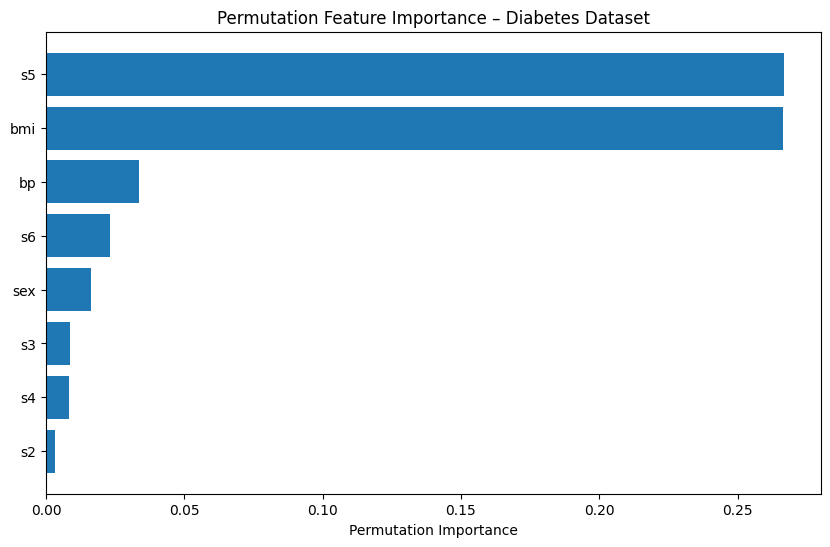

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][:8][::-1],
    importance_df["Importance"][:8][::-1]
)
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance – Diabetes Dataset")
plt.show()


Partial Dependence Plot (PDP)

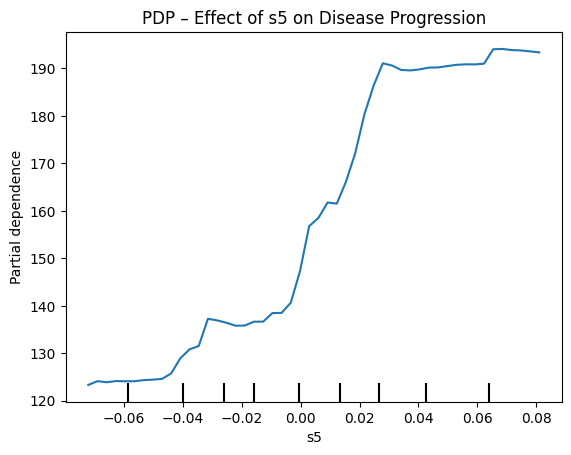

In [7]:
top_feature = importance_df.iloc[0]["Feature"]

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=[top_feature],
    grid_resolution=50
)

plt.title(f"PDP – Effect of {top_feature} on Disease Progression")
plt.show()


PDP for Multiple Medical Features

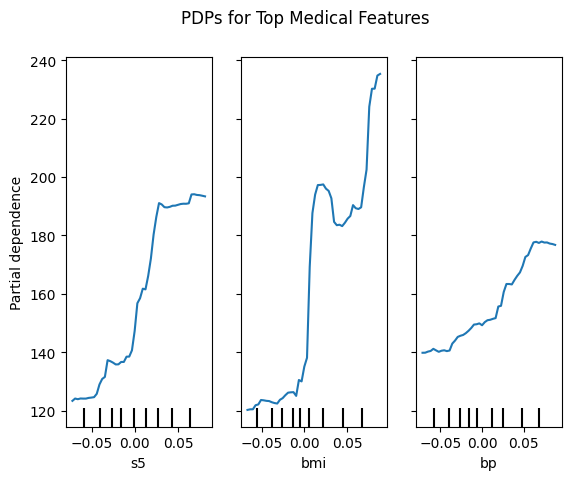

In [8]:
top_features = importance_df["Feature"].head(3).tolist()

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=top_features,
    grid_resolution=50
)

plt.suptitle("PDPs for Top Medical Features")
plt.show()


**Comparison & Interpretation**

**1.Permutation Feature Importance (PFI)**

Tells which medical variables matter most

Based on performance drop

Global explanation

Model-agnostic




**2.Partial Dependence Plot (PDP)**

Shows how feature values affect predictions

Average effect

Helps clinical interpretation (e.g., BMI vs disease severity)


**COMPARISON TABLE**


| Aspect          | Permutation Importance | PDP                 |
| --------------- | ---------------------- | ------------------- |
| Explains        | Feature importance     | Feature behavior    |
| Scope           | Global                 | Global (average)    |
| Output          | Importance score       | Prediction curve    |
| Medical Insight | Risk factor ranking    | Risk trend analysis |

 **Conclusion**

In medical prediction tasks, permutation feature importance identifies the most influential clinical factors by measuring prediction degradation, while partial dependence plots explain how these factors influence disease progression. Together, they provide transparent and clinically meaningful model interpretability.